### Step 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import gridspec

In [45]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef, confusion_matrix 

### Step 2: Loading the Data

In [29]:
data = pd.read_csv('./data/creditcard.csv')[:156612]

In [10]:
data.head(5)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [30]:
data.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,156612.000000,156612.000000,156612.000000,156612.000000,156612.000000,156612.000000,156612.000000,156612.000000,156612.000000,156612.000000,...,156612.000000,156612.000000,156612.000000,156612.000000,156612.000000,156612.000000,156612.000000,156612.000000,156612.000000,156612.000000
mean,56114.721286,-0.226386,0.048400,0.593047,0.138975,-0.226409,0.070155,-0.102408,0.046491,0.000108,...,-0.037757,-0.107724,-0.027037,0.009324,0.110157,0.019958,0.001358,0.002436,88.192934,0.002235
std,23396.766143,1.845422,1.623685,1.342722,1.359581,1.333429,1.291755,1.215749,1.247096,1.153651,...,0.748500,0.650179,0.589118,0.596356,0.453140,0.492832,0.394076,0.311974,246.282443,0.047221
min,0.000000,-56.407510,-72.715728,-33.680984,-5.519697,-42.147898,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-11.710896,0.000000,0.000000
25%,39715.750000,-1.015986,-0.535155,0.078529,-0.719061,-0.865280,-0.675734,-0.598388,-0.147495,-0.674371,...,-0.231040,-0.551275,-0.171226,-0.329200,-0.166790,-0.327062,-0.063969,-0.012231,5.850000,0.000000
50%,57468.500000,-0.252679,0.121515,0.696599,0.153738,-0.270188,-0.187679,-0.048729,0.069685,-0.099687,...,-0.060559,-0.084206,-0.040999,0.062536,0.151406,-0.056233,0.010348,0.022534,22.060000,0.000000
75%,74684.000000,1.167918,0.808932,1.335915,0.971439,0.307804,0.458521,0.439584,0.364539,0.616350,...,0.114576,0.324145,0.091124,0.411263,0.410005,0.286555,0.089524,0.078085,78.000000,0.000000
max,108499.000000,2.439207,22.057729,9.382558,16.875344,34.801666,22.529298,36.677268,20.007208,15.594995,...,27.202839,10.503090,19.002942,4.022866,7.519589,3.517346,12.152401,33.847808,19656.530000,1.000000


### Step 3: Analyzing Class Distribution

In [33]:
fraud = data[data['Class'] == 1]
valid = data[data['Class'] == 0]

In [34]:
outlierFraction = len(fraud) / len(valid)

In [35]:
print('Outlier Fraction:', outlierFraction, '\nFraud Cases:', len(fraud), '\nValid Transaction:', len(valid))

Outlier Fraction: 0.002239827981211043 
Fraud Cases: 350 
Valid Transaction: 156262


### Step 4: Exploring Transaction Amounts

In [20]:
print("Amount details of the fraudulent transaction")
fraud.Amount.describe()

Amount details of the fraudulent transaction


count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

In [21]:
print("details of valid transaction")
valid.Amount.describe()

details of valid transaction


count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

### Step 5: Plotting Correlation Matrix

In [31]:
corrmat = data.corr()

<Axes: >

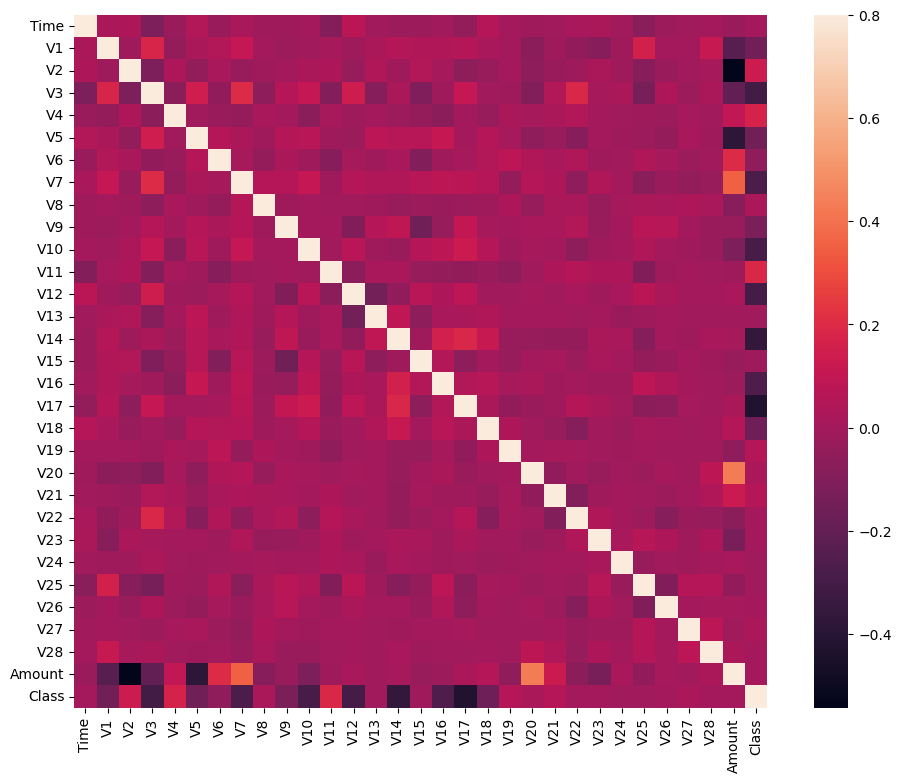

In [32]:
fig = plt.figure(figsize=(12, 9))
sns.heatmap(corrmat, vmax=.8, square=True)

### Step 6: Preparing Data

In [37]:
X = data.drop(['Class'], axis=1)
Y = data['Class']

In [39]:
xData = X.values
yData = Y.values

In [38]:
print(X.shape)
print(Y.shape)

(156612, 30)
(156612,)


In [40]:
xTrain, xTest, yTrain, yTest = train_test_split(
    xData,
    yData,
    test_size=0.2,
    random_state=42
)

### Step 7: Building and Training the Model

In [42]:
rfc = RandomForestClassifier()

In [43]:
rfc.fit(xTrain, yTrain)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [44]:
yPred = rfc.predict(xTest)

### Step 8: Evaluating the Model

In [46]:
accuracy = accuracy_score(yTest, yPred)
precision = precision_score(yTest, yPred)
recall = recall_score(yTest, yPred)
f1 = f1_score(yTest, yPred)
mcc = matthews_corrcoef(yTest, yPred)

In [47]:
print("Model Evaluation Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Matthews Correlation Coefficient: {mcc:.4f}")

Model Evaluation Metrics:
Accuracy: 0.9996
Precision: 0.8833
Recall: 0.8833
F1-Score: 0.8833
Matthews Correlation Coefficient: 0.8831


In [48]:
conf_matrix = confusion_matrix(yTest, yPred)

Text(70.72222222222221, 0.5, 'True Class')

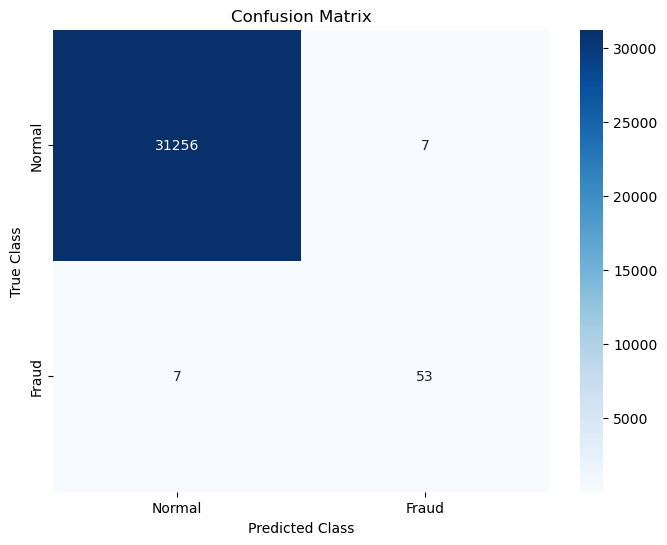

In [49]:
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")